--------------------------------------------------
# Image Processing with OpenCV
--------------------------------------------------

------------------------------
## Task 0 - Capture Your Own Image Set (Prerequisite, do this first)
------------------------------
Using your phone or laptop webcam, capture 5 original images/clips today:
* A photo of yourself or a teammate (with their OK) in normal lighting
* The same subject/scene in low light
* A photo with at least 3 distinct small objects (pens, coins, keys) scattered on a desk
* A photo of a printed or handwritten page held at a slight angle
* A short 15 to 20 second video of you moving an object across the frame

Keep the original files as-is (don't screenshot or pre-edit them). You'll reuse these across the tasks below. Save them in a raw_captures/ folder inside your onboarding directory.

In [1]:
# imported the std libraries said in the document
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

folder_path = "./raw_captures/"

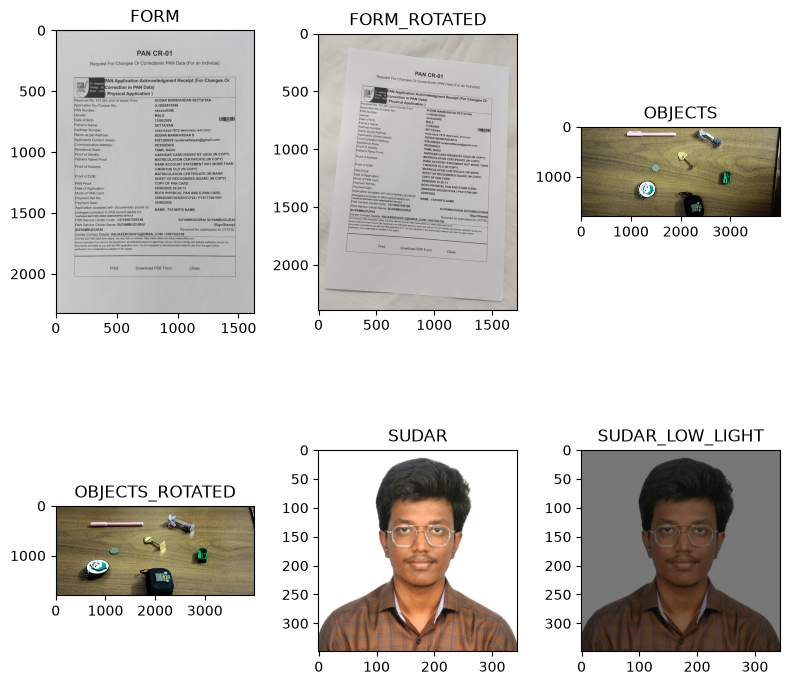

In [ ]:
import os

# thought we will need it often so made it as a function
def show_video(file_path):
    
    capture = cv.VideoCapture(os.path.join(folder_path, file_path))
    # print(os.path.join(folder_path, file_path))
    # check if opening file failes (due to permissions or error in format or API used)
    if not capture.isOpened():
        print("Can't open file.")
        exit(1)
        
    while True: # can also use cv.isOpen() function to check and exit
        status, frame = capture.read() 
            
        if not status:
            print("Video read successfully")
            break
        # control the size of window
        cv.namedWindow(str(file_path), cv.WINDOW_NORMAL)
        
        width = int(capture.get(cv.CAP_PROP_FRAME_WIDTH))
        height = int(capture.get(cv.CAP_PROP_FRAME_HEIGHT))
        
        center_w = (1920 - width) // 2
        center_h = (1080 - height) // 2
        
        cv.resizeWindow(str(file_path), width, height)
        cv.moveWindow(str(file_path), center_w, center_h)
        # display the frame
        cv.imshow(str(file_path), frame)
        
        # control the flow (using  0xFF as a filter to eliminate messy input scenarios)
        if cv.waitKey(30) & 0xFF == ord('q'):
            break
        
    capture.release()
    cv.destroyAllWindows()
    

allowed_extensions = (".jpeg", ".jpg", ".mp4")
fig, ax = plt.subplots(2, 3, figsize=(8, 8))
i = 0 

# display the  video and image stored in raw_captures folder
for file_path in sorted(os.listdir(folder_path)):
    
    if file_path.endswith(allowed_extensions) and (file_path.endswith("jpg") or file_path.endswith("jpeg")):
        row = i // 3; col = i % 3 
        # load and change the channel dim
        ax[row, col].imshow(cv.imread(os.path.join(folder_path, file_path))[:, :, :: -1])
        basename, _ = os.path.splitext(file_path)
        ax[row, col].set_title(basename.upper())
        # increment for next position
        i += 1
            
    elif file_path.endswith(".mp4"):
        show_video(file_path)

plt.tight_layout()
plt.show()   

-----------------------------------------
## Task 1 - Color Space Conversion
-------------------------------------------

Using your low-light photo, convert it to Grayscale, HSV, and RGB (remember OpenCV loads as BGR by default). Display all versions side by side.
Then, looking specifically at your own photo, note which HSV channel best preserves detail in the darkest part of the frame, and why you think that's the case for this particular shot.

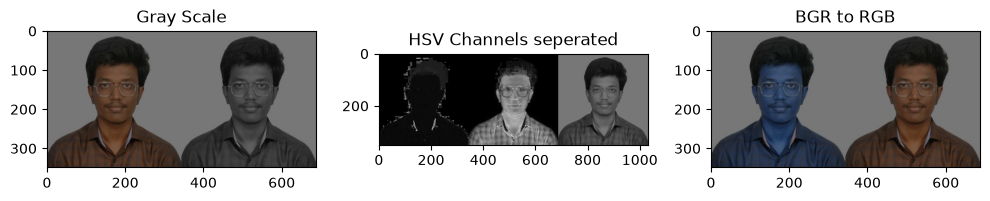

In [15]:
low_light_picture = "./raw_captures/sudar_low_light.jpg"
img = cv.imread(low_light_picture)

if img is None:
    print(f"Error: Could not load image from {low_light_picture}")
    exit()

display_option = {"G": "Gray Scale", "H": "HSV", "R": "RGB"}
fig, ax  = plt.subplots(1, 3, figsize=(10, 8))
while True:
    key = input("Enter a key G -> Gray Scale, H -> HSV, R -> RGB (Any other key to Quit): ").upper()
    
    if key == "G":
        result = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  
        display_result = cv.cvtColor(result, cv.COLOR_GRAY2BGR)
        combined_image = cv.hconcat([img, display_result])
        combined_img_plt = cv.hconcat([img[:, :, ::-1], display_result])
        ax[0].imshow(combined_img_plt)
        ax[0].set_title("Gray Scale")                
    elif key == "H":
        
        result = cv.cvtColor(img, cv.COLOR_BGR2HSV)
        # split channels and convert each to 3-channel BGR so cv.hconcat works without crash for 2nd time
        h, s, v = cv.split(result)
        h_bgr = cv.cvtColor(h, cv.COLOR_GRAY2BGR)
        s_bgr = cv.cvtColor(s, cv.COLOR_GRAY2BGR)
        v_bgr = cv.cvtColor(v, cv.COLOR_GRAY2BGR)
        
        # stack  H, S, V components
        combined_image = cv.hconcat([h_bgr, s_bgr, v_bgr])
        ax[1].imshow(combined_image)
        ax[1].set_title("HSV Channels seperated")
    elif key == "R":
        result = cv.cvtColor(img, cv.COLOR_BGR2RGB)
        combined_image = cv.hconcat([img, result])
        ax[2].imshow(combined_image)
        ax[2].set_title("BGR to RGB")
    else:
        break

    # Display the temporary side-by-side comparison window
    cv.imshow(f"Combined Result ({display_option[key]})", combined_image)
    cv.waitKey(0)
    cv.destroyAllWindows()
plt.tight_layout()
plt.show()

### Task 1 - Observation

- The Value channel preserves the facial features as it is, in a low light image than the Hue and Saturation channels.

- The Value region preserves the most visible structure in shadowed regions because it directly captures brightness variations.

- The hue channel is mostly noisy, because of the presence of low colour based information in the image.

- The saturation region is responsible for intensity, preserves some features but they are over emphasized like the shirt and skin tone the other areas lost the details. 